COVID-19 DATASET


,Date,Country,Confirmed,Deaths,Recovered,Active
0,2020-04-01,India,2000,60,150,1790
1,2020-04-01,USA,220000,5000,8000,207000
2,2020-04-01,Italy,110000,13100,17000,79900
3,2020-04-01,Brazil,7000,250,150,6600
4,2020-04-08,India,5200,150,450,4600
5,2020-04-08,USA,430000,14500,22000,393500
6,2020-04-08,Italy,140000,17600,24500,97900
7,2020-04-08,Brazil,15000,750,1200,13050
8,2020-04-15,India,12000,400,1400,10200
9,2020-04-15,USA,620000,25000,38000,557000



Dataset Shape:
(20, 6)

Missing Values:
Date         0
Country      0
Confirmed    0
Deaths       0
Recovered    0
Active       0
dtype: int64

Duplicate Records:
0

Statistical Summary:


,Date,Confirmed,Deaths,Recovered,Active
count,20,2.000000e+01,20.000000,20.000000,20.000000
mean,2020-04-15 00:00:00,2.115100e+05,13569.250000,26542.500000,171398.250000
min,2020-04-01 00:00:00,2.000000e+03,60.000000,150.000000,1790.000000
25%,2020-04-08 00:00:00,1.950000e+04,737.500000,3500.000000,15337.500000
50%,2020-04-15 00:00:00,9.500000e+04,5250.000000,15000.000000,64200.000000
75%,2020-04-22 00:00:00,2.087500e+05,22525.000000,38000.000000,135750.000000
max,2020-04-29 00:00:00,1.050000e+06,61000.000000,120000.000000,869000.000000
std,NaN,2.986747e+05,16995.085689,32387.124939,256859.051577



COUNTRY-WISE COVID STATISTICS


,Confirmed,Deaths,Recovered,Active
Country,,,,
Brazil,80000,5500,26000,48500
India,33000,1075,8300,23625
Italy,205000,27500,75000,112000
USA,1050000,61000,120000,869000


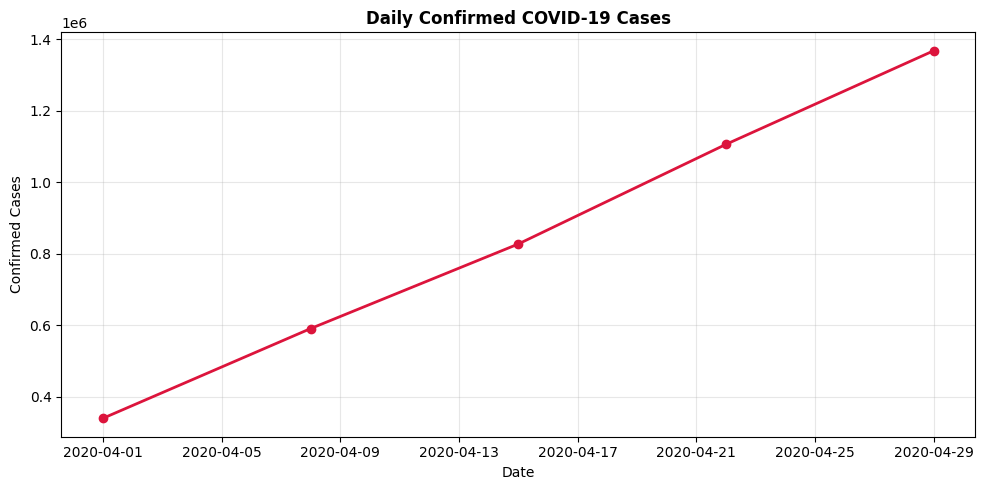

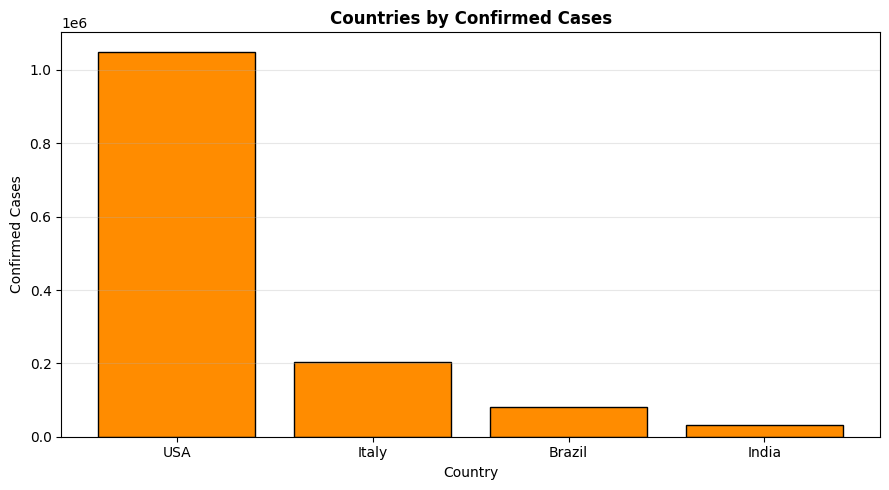

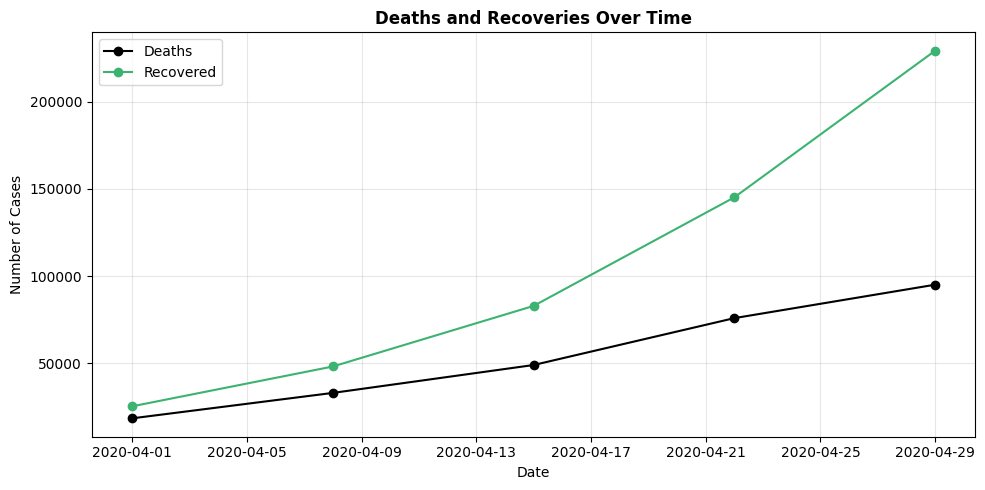

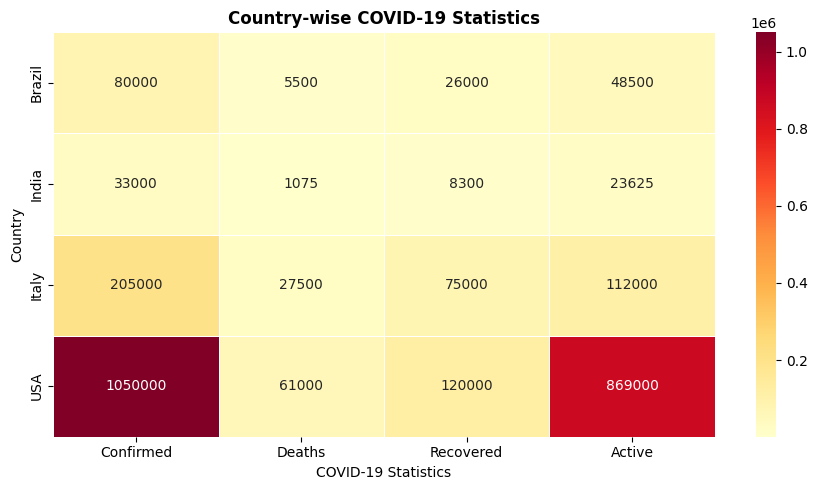

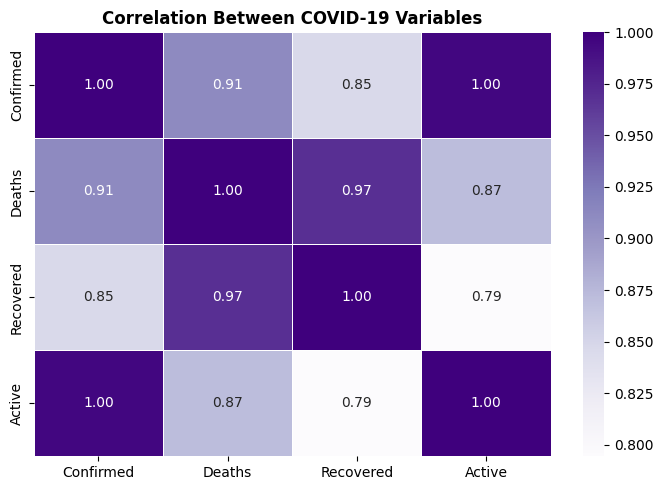

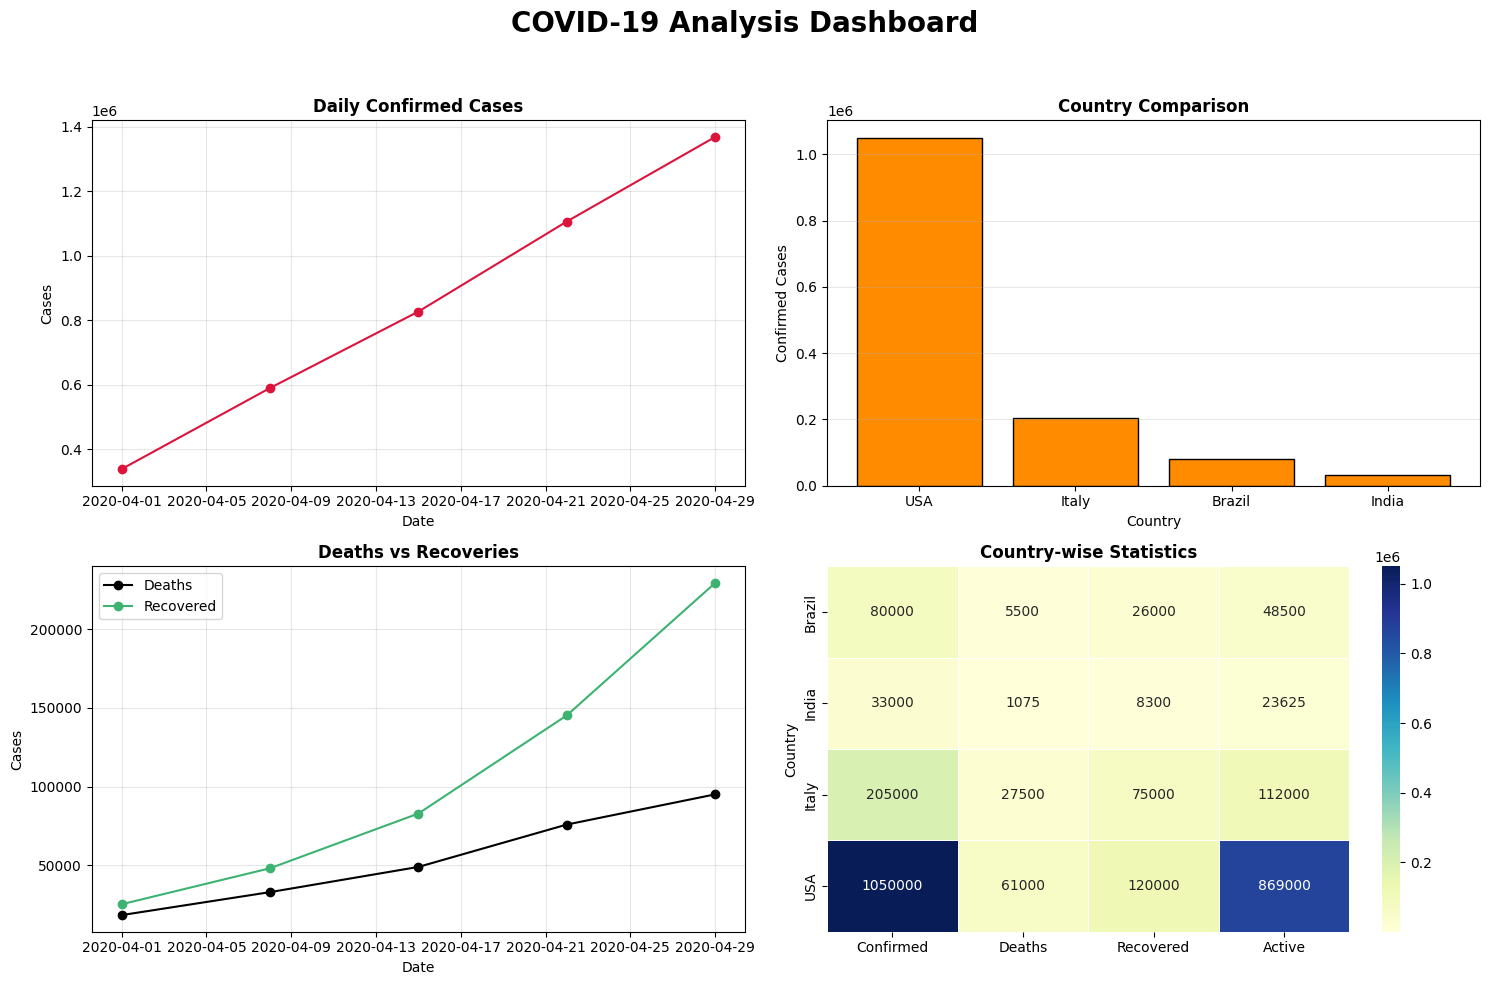


COUNTRIES WITH HIGHEST GROWTH:


,first,last,Growth
Country,,,
USA,220000,1050000,830000
Italy,110000,205000,95000
Brazil,7000,80000,73000
India,2000,33000,31000



KEY INSIGHTS:
1. Confirmed COVID-19 cases increased over the given period.
2. USA has the highest confirmed cases in this sample dataset.
3. The country-wise heatmap makes it easy to compare confirmed, death, recovered and active cases.
4. Deaths and recoveries show an increasing trend over time.
5. Confirmed cases, deaths, recoveries and active cases show relationships that can be studied using the correlation heatmap.
6. Growth analysis identifies the countries with the largest increase in confirmed cases.


In [1]:
# ============================================================
#              COVID-19 DATA ANALYSIS
#        Creating Our Own Dataset
# ============================================================

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# STEP 2: CREATE OUR OWN COVID DATASET
# ============================================================

data = {
    "Date": [
        "2020-04-01", "2020-04-01", "2020-04-01", "2020-04-01",
        "2020-04-08", "2020-04-08", "2020-04-08", "2020-04-08",
        "2020-04-15", "2020-04-15", "2020-04-15", "2020-04-15",
        "2020-04-22", "2020-04-22", "2020-04-22", "2020-04-22",
        "2020-04-29", "2020-04-29", "2020-04-29", "2020-04-29"
    ],

    "Country": [
        "India", "USA", "Italy", "Brazil",
        "India", "USA", "Italy", "Brazil",
        "India", "USA", "Italy", "Brazil",
        "India", "USA", "Italy", "Brazil",
        "India", "USA", "Italy", "Brazil"
    ],

    "Confirmed": [
        2000, 220000, 110000, 7000,
        5200, 430000, 140000, 15000,
        12000, 620000, 165000, 30000,
        21000, 850000, 185000, 50000,
        33000, 1050000, 205000, 80000
    ],

    "Deaths": [
        60, 5000, 13100, 250,
        150, 14500, 17600, 750,
        400, 25000, 21700, 1900,
        700, 47000, 25000, 3200,
        1075, 61000, 27500, 5500
    ],

    "Recovered": [
        150, 8000, 17000, 150,
        450, 22000, 24500, 1200,
        1400, 38000, 38000, 5500,
        4200, 80000, 48000, 13000,
        8300, 120000, 75000, 26000
    ],

    "Active": [
        1790, 207000, 79900, 6600,
        4600, 393500, 97900, 13050,
        10200, 557000, 105300, 22600,
        16100, 723000, 112000, 33800,
        23625, 869000, 102500, 48500
    ]
}


# Convert dictionary into DataFrame
df = pd.DataFrame(data)

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])


# ============================================================
# STEP 3: INSPECT DATASET
# ============================================================

print("COVID-19 DATASET")
display(df)

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())


# ============================================================
# STEP 4: COUNTRY-WISE TOTAL STATISTICS
# ============================================================

country_stats = df.groupby("Country")[
    ["Confirmed", "Deaths", "Recovered", "Active"]
].max()

print("\nCOUNTRY-WISE COVID STATISTICS")
display(country_stats)


# ============================================================
# 1. DAILY CONFIRMED CASES
# ============================================================

daily_cases = df.groupby("Date")["Confirmed"].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    daily_cases.index,
    daily_cases.values,
    marker="o",
    color="crimson",
    linewidth=2
)

plt.title(
    "Daily Confirmed COVID-19 Cases",
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 2. COUNTRY COMPARISON
# ============================================================

country_confirmed = (
    country_stats["Confirmed"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    country_confirmed.index,
    country_confirmed.values,
    color="darkorange",
    edgecolor="black"
)

plt.title(
    "Countries by Confirmed Cases",
    fontweight="bold"
)

plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. DEATHS AND RECOVERIES OVER TIME
# ============================================================

daily_stats = df.groupby("Date")[
    ["Deaths", "Recovered"]
].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    daily_stats.index,
    daily_stats["Deaths"],
    marker="o",
    color="black",
    label="Deaths"
)

plt.plot(
    daily_stats.index,
    daily_stats["Recovered"],
    marker="o",
    color="mediumseagreen",
    label="Recovered"
)

plt.title(
    "Deaths and Recoveries Over Time",
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Number of Cases")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4. COUNTRY-WISE HEATMAP
# ============================================================

plt.figure(figsize=(9, 5))

sns.heatmap(
    country_stats,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title(
    "Country-wise COVID-19 Statistics",
    fontweight="bold"
)

plt.xlabel("COVID-19 Statistics")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


# ============================================================
# 5. CORRELATION HEATMAP
# ============================================================

correlation = df[
    ["Confirmed", "Deaths", "Recovered", "Active"]
].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Between COVID-19 Variables",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. COVID-19 DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle(
    "COVID-19 Analysis Dashboard",
    fontsize=20,
    fontweight="bold"
)


# Daily confirmed cases
axes[0, 0].plot(
    daily_cases.index,
    daily_cases.values,
    marker="o",
    color="crimson"
)

axes[0, 0].set_title(
    "Daily Confirmed Cases",
    fontweight="bold"
)

axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Cases")
axes[0, 0].grid(True, alpha=0.3)


# Country comparison
axes[0, 1].bar(
    country_confirmed.index,
    country_confirmed.values,
    color="darkorange",
    edgecolor="black"
)

axes[0, 1].set_title(
    "Country Comparison",
    fontweight="bold"
)

axes[0, 1].set_xlabel("Country")
axes[0, 1].set_ylabel("Confirmed Cases")
axes[0, 1].grid(axis="y", alpha=0.3)


# Deaths and recoveries
axes[1, 0].plot(
    daily_stats.index,
    daily_stats["Deaths"],
    marker="o",
    color="black",
    label="Deaths"
)

axes[1, 0].plot(
    daily_stats.index,
    daily_stats["Recovered"],
    marker="o",
    color="mediumseagreen",
    label="Recovered"
)

axes[1, 0].set_title(
    "Deaths vs Recoveries",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Cases")

axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)


# Heatmap
sns.heatmap(
    country_stats,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Country-wise Statistics",
    fontweight="bold"
)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ============================================================
# FINAL QUESTION:
# COUNTRIES WITH HIGHEST GROWTH
# ============================================================

growth = (
    df.groupby("Country")["Confirmed"]
    .agg(["first", "last"])
)

growth["Growth"] = growth["last"] - growth["first"]

print("\nCOUNTRIES WITH HIGHEST GROWTH:")
display(
    growth.sort_values(
        "Growth",
        ascending=False
    )
)


# ============================================================
# FINAL INSIGHTS
# ============================================================

print("\nKEY INSIGHTS:")

print("1. Confirmed COVID-19 cases increased over the given period.")

print("2. USA has the highest confirmed cases in this sample dataset.")

print("3. The country-wise heatmap makes it easy to compare confirmed, death, recovered and active cases.")

print("4. Deaths and recoveries show an increasing trend over time.")

print("5. Confirmed cases, deaths, recoveries and active cases show relationships that can be studied using the correlation heatmap.")

print("6. Growth analysis identifies the countries with the largest increase in confirmed cases.")

In [ ]:
# The country-wise COVID-19 heatmap provides visual evidence of the countries most affected during the given period. The heatmap compares Confirmed, Deaths, Recovered, and Active cases across countries using color intensity. The USA shows the darkest cells and the highest values, with 1,050,000 confirmed cases, 61,000 deaths, 120,000 recoveries, and 869,000 active cases. Italy also shows relatively high values, while India and Brazil have lower values in comparison. Therefore, based on the heatmap, the USA appears to be the most affected country in this sample dataset.

